# Regresión para clasificación (Regresión Logística)

**Date** 11/11/2025

In [1]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
diabetes = datasets.load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [3]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
# columns
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [5]:
# Now we will split the data into the independent and independent variable
X = diabetes.data
Y = diabetes.target

In [6]:
X.shape, Y.shape

((442, 10), (442,))

In [7]:
Y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [6]:
# Dividimos los datos en train y test
from sklearn.model_selection import train_test_split

In [7]:
train_x, test_x, train_y, test_y = train_test_split(X,Y,test_size=0.2,random_state=12345)

In [8]:
train_x.shape, train_y.shape

((353, 10), (353,))

Ahora usaremos el modelo de regresión:

In [11]:
# Linear Regression
from sklearn.linear_model import LinearRegression

In [12]:
le = LinearRegression()

In [13]:
le.fit(train_x,train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = le.predict(test_x)
y_pred

array([ 77.9991034 , 170.44712136, 109.03660582, 223.84307065,
        87.38430375, 211.46934588, 223.65994161,  52.81888351,
       149.39008619, 294.9893952 , 127.72956377, 182.90399415,
       102.6375881 , 144.69460471, 171.5213581 , 266.17922455,
       201.8877034 , 166.18209687, 103.67082991, 169.01866852,
       187.13785171, 130.10161695, 151.54411583, 156.45841795,
       121.85578431, 304.14149903, 126.55107098, 158.76430506,
       249.42202516, 154.22310276, 180.85528758, 180.06909853,
       182.96467155, 200.00132316,  73.87031841, 146.19357531,
       165.52522033, 160.93215348, 247.99028596, 210.37177183,
        85.69905264, 211.07539533, 188.10590426, 119.60434815,
       151.80766971, 188.31163328, 185.69251949, 168.92581539,
       291.55993431, 248.60092291, 170.17035216, 208.5515447 ,
        59.08071813, 195.30432554, 190.19923551, 149.97489689,
       114.4835119 , 244.83078249, 254.54782428, 138.88949628,
       301.05425333,  57.71483254, 162.93256009, 187.59

In [15]:
result = pd.DataFrame({'Actual': test_y, 'Predict' : y_pred})
result

,Actual,Predict
0,75.0,77.999103
1,128.0,170.447121
2,125.0,109.036606
3,332.0,223.843071
4,37.0,87.384304
...,...,...
128,48.0,202.349391
129,172.0,144.663523
130,51.0,82.400892
131,277.0,185.443544


In [16]:
# we will check the accuracy

print('coefficient', le.coef_)
print('intercept', le.intercept_)

coefficient [  40.66179183 -313.2934701   517.18345014  386.06561935 -604.64289258
  275.31448303    3.92015562  172.39101348  661.95332633   62.26068823]
intercept 155.59120125597175


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
# mean_squared_error
mean_squared_error(test_y,y_pred)

3157.972848565651

In [20]:
# r2 score
r2_score(test_y,y_pred)

0.4545709909725648

In [29]:
from sklearn.neighbors import KNeighborsRegressor

neighbours = [2, 5, 10, 20, 50, 70, 100, 130, 150,200]

models_regresion = {
    i: KNeighborsRegressor(n_neighbors=i)
    for i in neighbours
    }

In [30]:
errors_train = []
errors_test = []

for model_name in models_regresion.keys():

    print("Modelo:", model_name)
    model = models_regresion[model_name]

    # Ajusta el modelo con los datos de prueba
    model.fit(train_x,train_y)

    y_train_pred = model.predict(train_x)
    y_test_pred = model.predict(test_x)

    # error en conjunto de entrenamiento y prueba
    error_train = mean_squared_error(train_y, y_train_pred)
    error_test = mean_squared_error(test_y, y_test_pred)

    errors_train.append(error_train)
    errors_test.append(error_test)

    # errores
    print("Error RSME en train:", round(error_train,2) )
    print("Error RSME en test:", round(error_test,2) )

    print("----------------------------------------------")

    


Modelo: 2
Error RSME en train: 1615.85
Error RSME en test: 4160.57
----------------------------------------------
Modelo: 5
Error RSME en train: 2417.88
Error RSME en test: 3575.01
----------------------------------------------
Modelo: 10
Error RSME en train: 2828.14
Error RSME en test: 3390.79
----------------------------------------------
Modelo: 20
Error RSME en train: 2982.5
Error RSME en test: 3257.42
----------------------------------------------
Modelo: 50
Error RSME en train: 3195.17
Error RSME en test: 3415.8
----------------------------------------------
Modelo: 70
Error RSME en train: 3314.53
Error RSME en test: 3407.22
----------------------------------------------
Modelo: 100
Error RSME en train: 3591.65
Error RSME en test: 3598.95
----------------------------------------------
Modelo: 130
Error RSME en train: 3813.56
Error RSME en test: 3775.95
----------------------------------------------
Modelo: 150
Error RSME en train: 3976.98
Error RSME en test: 3906.29
-------------

In [31]:
knn_errors_train = pd.DataFrame(
    {
        "k": neighbours,
        "type": "train",
        "rmse": errors_train,
    }
)

knn_errors_test = pd.DataFrame(
    {
        "k": neighbours,
        "type": "test",
        "rmse": errors_test,
    }
)

In [32]:
knn_errors = pd.DataFrame(
    {
        "k": neighbours,
        "rmse_train": errors_train,
        "rmse_test": errors_test
    }
)

knn_errors

,k,rmse_train,rmse_test
0,2,1615.854369,4160.565789
1,5,2417.878317,3575.006917
2,10,2828.136311,3390.790752
3,20,2982.497791,3257.421372
4,50,3195.169746,3415.795098
5,70,3314.532705,3407.224674
6,100,3591.654364,3598.947123
7,130,3813.559574,3775.948986
8,150,3976.984396,3906.294079
9,200,4459.901945,4406.228717


<Axes: xlabel='k', ylabel='rmse'>

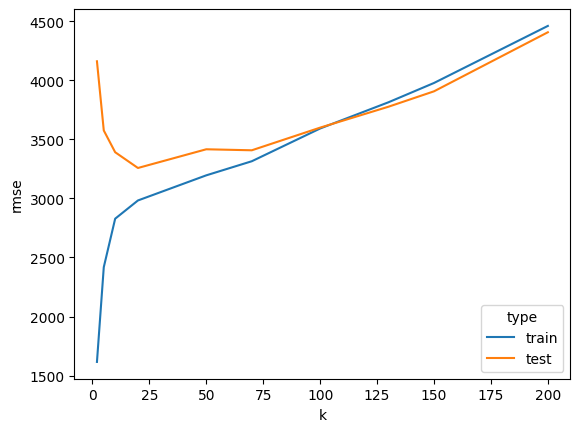

In [33]:
import seaborn as sns
sns.lineplot(
    pd.concat([knn_errors_train, knn_errors_test]),
    x="k",
    y="rmse",
    hue="type",
    markers=True, dashes=True
)

In [54]:
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    ElasticNet
)

# Instanciamos los diferentes modelos
lr = LinearRegression()
lr_lasso = Lasso(alpha=0.0000)
lr_ridge = Ridge(alpha=0.0002)
lr_elastict = ElasticNet(alpha=0.001, l1_ratio=0.0001)

models_regresion = {
    'regression': lr,
    'lasso': lr_lasso,
    'ridge': lr_ridge,
    'elastic': lr_elastict
    }

In [55]:
errors_train = []
errors_test = []

for model_name in models_regresion.keys():

    print("Modelo:", model_name)
    model = models_regresion[model_name]

    # Ajusta el modelo con los datos de prueba
    model.fit(train_x,train_y)

    y_train_pred = model.predict(train_x)
    y_test_pred = model.predict(test_x)

    # error en conjunto de entrenamiento y prueba
    error_train = mean_squared_error(train_y, y_train_pred)
    error_test = mean_squared_error(test_y, y_test_pred)

    errors_train.append(error_train)
    errors_test.append(error_test)
    
    # errores
    print("Error RSME en train:", round(error_train,2) )
    print("Error RSME en test:", round(error_test,2) )

    print("----------------------------------------------")

Modelo: regression
Error RSME en train: 2783.62
Error RSME en test: 3157.97
----------------------------------------------
Modelo: lasso
Error RSME en train: 2783.62
Error RSME en test: 3157.97
----------------------------------------------
Modelo: ridge
Error RSME en train: 2783.63
Error RSME en test: 3158.49
----------------------------------------------
Modelo: elastic
Error RSME en train: 2945.52
Error RSME en test: 3120.64
----------------------------------------------


/Users/cesar/sandbox/ai_programming_foundations/venv/lib/python3.12/site-packages/sklearn/base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Users/cesar/sandbox/ai_programming_foundations/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Users/cesar/sandbox/ai_programming_foundations/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.301e+05, tolerance: 1.851e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one 

In [49]:
np.argmin(errors_test)

np.int64(3)

In [50]:
list(models_regresion.keys())[3]

'elastic'